# PHASE 0.8 — Validated decision

## What Phase 0.7 established

The verdict was **METHOD CONTRIBUTION SUPPORTED**, and the diagnosis of C6's collapse was
confirmed beyond doubt:

| Standardiser | \|z\| max | p99 | fraction \|z\| > 5 |
|---|---|---|---|
| clean-fit (the arm that collapsed) | **651,943** | 325,522 | 16.7% |
| aug-fit | 47.1 | 8.41 | 1.9% |
| robust (σ floor + clipping) | 5.0 | 5.00 | 0% |

Some class × dimension pairs had a near-zero standard deviation on clean data, and dividing by it
produced *z* values in the hundreds of thousands. Fixing the fit distribution alone was **not**
enough — C6b still collapsed at `T_min` 0.0101. Only the variance floor plus clipping made it
sound.

Bootstraps on the winning arm: C4 beat C2 on NLL (Δ −0.0593, CI [−0.0654, −0.0535]) and on ECE
(Δ −0.0419, CI [−0.0444, −0.0388]). C4 beat the content-only control C5 on NLL (Δ −0.2451,
CI [−0.2976, −0.1948]) and tied it exactly on ECE (Δ 0.0000, CI [−0.0085, 0.0086]).

## Three problems this notebook fixes

**1. The arm was selected on the test set.** `best_q = min(..., key=lambda n: R.loc[n,"nll"])`
read `R`, which was computed on the test fold. That is test-set model selection, and no reviewer
would let it stand. Selection now happens on a dedicated split that is disjoint from both the
calibration data and the test fold.

**2. Selection used the reported corruption families.** Even with disjoint images, choosing the
arm using the six held-out families weakens the claim that those families are held out. Primary
selection therefore uses the **train** families; the test-family variant is reported alongside as
a sensitivity check. If both pick the same arm the question is moot, and if they disagree, that
disagreement is the finding.

**3. Everything rested on one fold, one seed.** This was the weakest part of the evidence — and
it is nearly free to fix, because the feature cache already covers every image under every
condition. Refitting the probe and the calibrators for the other four folds costs seconds, not a
second extraction. All five cross-validation folds now run, with mean ± SD across folds.

**One more statistical correction.** Phase 0.7 bootstrapped over test *rows*, but each image
appears 30 times (six families × five severities). The sampling unit is the image, so resampling
rows is misspecified. This notebook resamples **images**.

Whether that widens or narrows the interval depends on the intra-cluster correlation, and is a
property of the data rather than of the estimator — verified across regimes, the image bootstrap
comes out 5.1× wider when within-image observations are strongly positively correlated, 2.1×
wider when mildly so, and equal when they are independent. Both intervals are therefore reported
side by side rather than asserting a direction.

## What the trade-off looks like so far

C6c — the leakage-corrected arm, once repaired — had the **best ECE of any arm** (0.0712 vs C4's
0.0910 and C2's 0.1333) but a **worse NLL than the scalar baseline** (0.8934 vs 0.8270). C4 wins
likelihood; C6c wins calibration error. Both are numerically sound. That is a real trade-off, and
it was never tested for significance because Phase 0.7 only bootstrapped its single chosen arm.
Every sound arm is now compared against both C2 and C5.

## 0. Self-contained core module

In [ ]:
CORE_V2 = r"""
import math, hashlib
import numpy as np, cv2

def _clip(x): return np.clip(x, 0, 1)
def _mask3(mask, x): return mask[..., None] if x.ndim == 3 else mask

# ------------------------------------------------------------------ optics --
def defocus_blur(x, s):
    r = [1, 2, 3, 5, 7][s-1]
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*r+1, 2*r+1)).astype(np.float32)
    return _clip(cv2.filter2D(x, -1, k/k.sum()))

def motion_blur(x, s):
    ksz = [5, 9, 13, 19, 25][s-1]
    ang = np.random.uniform(0, 180)
    k = np.zeros((ksz, ksz), np.float32); k[ksz//2, :] = 1.0
    M = cv2.getRotationMatrix2D((ksz/2-.5, ksz/2-.5), ang, 1.0)
    k = cv2.warpAffine(k, M, (ksz, ksz))
    return _clip(cv2.filter2D(x, -1, k/k.sum()))

def vignetting(x, s):
    st = [0.15, 0.30, 0.45, 0.62, 0.80][s-1]
    h, w = x.shape[:2]; yy, xx = np.mgrid[0:h, 0:w]
    r = np.sqrt(((xx-w/2)/(w/2))**2 + ((yy-h/2)/(h/2))**2)
    m = np.clip(1 - st*np.clip(r-0.4, 0, None)/0.6, 0, 1).astype(np.float32)
    return _clip(x * _mask3(m, x))

def lens_contamination(x, s):
    n = [3, 7, 13, 22, 34][s-1]; h, w = x.shape[:2]
    blurred = cv2.GaussianBlur(x, (0, 0), sigmaX=max(1.0, min(h, w)/40))
    mask = np.zeros((h, w), np.float32)
    for _ in range(n):
        c = (np.random.randint(0, w), np.random.randint(0, h))
        rad = np.random.randint(max(2, int(0.015*w)), max(4, int(0.07*w)))
        cv2.circle(mask, c, rad, 1.0, -1, lineType=cv2.LINE_AA)
    mask = cv2.GaussianBlur(mask, (0, 0), sigmaX=max(1.0, min(h, w)/60))
    m = _mask3(mask, x)                       # guard: 2-D input used to broadcast to (H,W,W)
    return _clip((x*(1-m) + blurred*m) * (1 - 0.25*m))

def vibration_jitter(x, s):
    amp = [0.6, 1.4, 2.6, 4.2, 6.5][s-1]; h, w = x.shape[:2]
    dx, dy = np.random.uniform(-amp, amp, 2)
    out = cv2.warpAffine(x, np.float32([[1, 0, dx], [0, 1, dy]]), (w, h),
                         flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    ksz = int(max(3, 2*round(amp)+1))
    k = np.zeros((ksz, ksz), np.float32); k[ksz//2, :] = 1.0
    M2 = cv2.getRotationMatrix2D((ksz/2-.5, ksz/2-.5), math.degrees(math.atan2(dy, dx)), 1.0)
    k = cv2.warpAffine(k, M2, (ksz, ksz))
    return _clip(cv2.filter2D(out, -1, k/max(k.sum(), 1e-8)))

# ------------------------------------------------------------------ sensor --
def gaussian_noise(x, s):
    return _clip(x + np.random.normal(0, [0.03, 0.06, 0.10, 0.16, 0.24][s-1], x.shape))

def shot_noise(x, s):
    lam = [80, 35, 15, 7, 3][s-1]
    return _clip(np.random.poisson(x*lam)/float(lam))

def scanline_banding(x, s):
    amp = [0.03, 0.06, 0.11, 0.17, 0.25][s-1]; h = x.shape[0]
    period = np.random.uniform(3, 22); phase = np.random.uniform(0, 2*np.pi)
    b = (1 + amp*np.sin(2*np.pi*np.arange(h)/period + phase)).astype(np.float32)
    return _clip(x * (b[:, None, None] if x.ndim == 3 else b[:, None]))

# ------------------------------------------------------------- photometric --
def illumination_gradient(x, s):
    st = [0.10, 0.20, 0.32, 0.46, 0.62][s-1]; h, w = x.shape[:2]
    ang = np.random.uniform(0, 2*np.pi); yy, xx = np.mgrid[0:h, 0:w]
    u = (xx/w-.5)*np.cos(ang) + (yy/h-.5)*np.sin(ang)
    g = (1 + st*u/(np.abs(u).max()+1e-8)).astype(np.float32)
    return _clip(x * _mask3(g, x))

def brightness_drift(x, s):
    # v2: gamma instead of an additive offset. Gamma maps [0,1] -> [0,1] and CANNOT clip.
    # v1 saturated 36.8% of pixels at severity 5 on Magnetic Tile, which destroyed dynamic
    # range rather than shifting brightness and made the top of the ladder meaningless.
    g = [1.12, 1.26, 1.45, 1.72, 2.05][s-1]
    if np.random.rand() < 0.5: g = 1.0/g
    return _clip(np.power(_clip(x), g))

def contrast_loss(x, s):
    g = [0.80, 0.65, 0.50, 0.36, 0.24][s-1]
    m = x.mean(axis=(0, 1), keepdims=True)
    return _clip((x-m)*g + m)

# ---------------------------------------------------------------- pipeline --
def jpeg_compression(x, s):
    q = [70, 50, 32, 18, 9][s-1]
    src = (x[..., ::-1]*255).astype(np.uint8) if x.ndim == 3 else (x*255).astype(np.uint8)
    _, enc = cv2.imencode(".jpg", src, [int(cv2.IMWRITE_JPEG_QUALITY), q])
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR if x.ndim == 3 else cv2.IMREAD_GRAYSCALE)
    return (dec[..., ::-1] if x.ndim == 3 else dec).astype(np.float32)/255.

CORRUPTIONS = {
    "defocus_blur": defocus_blur, "motion_blur": motion_blur, "vignetting": vignetting,
    "lens_contamination": lens_contamination, "vibration_jitter": vibration_jitter,
    "gaussian_noise": gaussian_noise, "shot_noise": shot_noise,
    "scanline_banding": scanline_banding, "illumination_gradient": illumination_gradient,
    "brightness_drift": brightness_drift, "contrast_loss": contrast_loss,
    "jpeg": jpeg_compression,
}
TRAIN_FAMILIES = ["defocus_blur", "gaussian_noise", "illumination_gradient",
                  "jpeg", "lens_contamination", "scanline_banding"]
TEST_FAMILIES  = ["motion_blur", "shot_noise", "brightness_drift",
                  "contrast_loss", "vignetting", "vibration_jitter"]
SEVERITIES = [1, 2, 3, 4, 5]
CONDITIONS = [("clean", 0)] + [(f, s) for f in CORRUPTIONS for s in SEVERITIES]


def corruption_seed(image_id, family, severity=None):
    # Depends on (image_id, family) only, NOT severity: nuisance parameters (blur angle,
    # banding period, blob positions, gradient orientation) stay fixed so that severity is
    # the sole varying factor. Seeding on severity too made scanline_banding score 0.20.
    h = hashlib.sha256(f"{image_id}|{family}".encode()).digest()
    return int.from_bytes(h[:4], "little")


def apply_corruption(img_u8, family, severity, image_id=None, seed=None):
    if family == "clean":
        return img_u8
    if seed is None and image_id is not None:
        seed = corruption_seed(image_id, family)
    st = None
    if seed is not None:
        st = np.random.get_state(); np.random.seed(seed % (2**32))
    try:
        out = CORRUPTIONS[family](img_u8.astype(np.float32)/255., severity)
    finally:
        if st is not None: np.random.set_state(st)
    return (np.clip(out, 0, 1)*255).astype(np.uint8)


# ------------------------------------------------------- quality descriptors -
def _gray(im):
    g = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY) if im.ndim == 3 else im
    return g.astype(np.float32)/255.

def _sharp(im): return float(cv2.Laplacian(_gray(im), cv2.CV_32F).var())

def _noise(im):
    g = _gray(im); h, w = g.shape
    M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], np.float32)
    return float(np.abs(cv2.filter2D(g, -1, M)).sum()*math.sqrt(math.pi/2) /
                 (6*max(w-2, 1)*max(h-2, 1)))

def _block(im):
    dh = np.abs(np.diff(_gray(im), axis=1))
    on = dh[:, 7::8].mean() if dh.shape[1] > 8 else 0.0
    return float(on/(dh.mean()+1e-8) - 1.0)

def _hf(im):
    g = _gray(im); f = np.abs(np.fft.fftshift(np.fft.fft2(g))); h, w = g.shape
    cy, cx = h//2, w//2; r = max(4, min(h, w)//8)
    return float(1.0 - f[cy-r:cy+r, cx-r:cx+r].sum()/(f.sum()+1e-8))


def quality_descriptor(img_u8):
    # 8-d ABSOLUTE no-reference descriptor (unchanged from v1).
    g = _gray(img_u8); h, w = g.shape
    if img_u8.ndim == 3:
        rg = img_u8[..., 0].astype(np.float32) - img_u8[..., 1]
        yb = .5*(img_u8[..., 0].astype(np.float32) + img_u8[..., 1]) - img_u8[..., 2]
        colour = float((np.sqrt(rg.std()**2 + yb.std()**2)
                        + .3*np.sqrt(rg.mean()**2 + yb.mean()**2))/255.)
    else:
        colour = 0.0
    cen = g[h//4:3*h//4, w//4:3*w//4]
    per = (g.sum()-cen.sum())/max(g.size-cen.size, 1)
    v = np.array([math.log1p(max(_sharp(img_u8), 0.)*1e3), _hf(img_u8),
                  math.log1p(max(_noise(img_u8), 0.)*1e3), _block(img_u8),
                  float(g.mean()), float(g.std()), colour,
                  float(cen.mean()/(per+1e-8))], np.float32)
    return np.nan_to_num(v, nan=0., posinf=0., neginf=0.)


def quality_descriptor_relative(img_u8):
    # 8-d PERTURBATION-RESPONSE descriptor: how much does a statistic move when a known
    # perturbation is applied? Higher severity signal than the absolute set (0.324 vs 0.236
    # on the synthetic benchmark) but NO reduction in class leakage on its own -- ratios
    # remove the absolute texture level, not the spectral shape. Use with class-conditional
    # standardisation, never alone.
    g8 = (_gray(img_u8)*255).astype(np.uint8); eps = 1e-8
    b = cv2.GaussianBlur(g8, (0, 0), 1.5)
    dn = cv2.resize(cv2.resize(g8, (max(2, g8.shape[1]//2), max(2, g8.shape[0]//2)),
                               interpolation=cv2.INTER_AREA),
                    (g8.shape[1], g8.shape[0]), interpolation=cv2.INTER_LINEAR)
    rn = np.random.default_rng(12345)
    nz = np.clip(g8.astype(np.float32) + rn.normal(0, 12, g8.shape), 0, 255).astype(np.uint8)
    _, e = cv2.imencode(".jpg", g8, [int(cv2.IMWRITE_JPEG_QUALITY), 40])
    jp = cv2.imdecode(e, cv2.IMREAD_GRAYSCALE)
    kh = np.zeros((9, 9), np.float32); kh[4, :] = 1/9.
    hb = cv2.filter2D(g8.astype(np.float32), -1, kh).astype(np.uint8)
    vb = cv2.filter2D(g8.astype(np.float32), -1, kh.T).astype(np.uint8)
    x = g8.astype(np.float32)/255.
    v = np.array([
        math.log((_sharp(g8)+eps)/(_sharp(b)+eps)),
        math.log((_sharp(g8)+eps)/(_sharp(dn)+eps)),
        math.log((_noise(nz)+eps)/(_noise(g8)+eps)),
        _block(jp) - _block(g8),
        float(((x+0.25) > 1.0).mean() + ((x-0.25) < 0.0).mean()),
        abs(math.log((_sharp(hb)+eps)/(_sharp(vb)+eps))),
        math.log((_hf(g8)+eps)/(_hf(b)+eps)),
        math.log((_gray(g8).std()+eps)/(_gray(b).std()+eps)),
    ], np.float32)
    return np.nan_to_num(v, nan=0., posinf=0., neginf=0.)


QUALITY_NAMES = ["sharpness", "hf_energy", "noise", "blockiness",
                 "luminance_mean", "luminance_std", "colourfulness", "vignette_ratio"]
RELATIVE_NAMES = ["blur_headroom", "resolution_headroom", "noise_headroom",
                  "compression_headroom", "clipping_headroom", "blur_anisotropy",
                  "hf_retention", "contrast_retention"]
QUALITY_DIM = 8


class ClassConditionalStandardiser:
    # z = (q - mu_c) / sigma_c, with mu_c and sigma_c estimated on DEVELOPMENT data only.
    #
    # Rationale: degradation is relative. A blurry-looking crazing image and a sharp-looking
    # patches image can have identical absolute sharpness; what makes one degraded is that it
    # is blurrier than crazing images normally are. Removing the class-conditional mean strips
    # the content component and leaves the deviation-from-typical -- which is the degradation.
    #
    # At test time c is the model's own prediction. There is no feedback loop: a per-image
    # scalar temperature cannot change the argmax, so the prediction is fixed before the
    # calibrator runs.
    def __init__(self, n_classes):
        self.n_classes = n_classes; self.mu = None; self.sd = None

    def fit(self, q, y):
        d = q.shape[1]
        self.mu = np.zeros((self.n_classes, d), np.float32)
        self.sd = np.ones((self.n_classes, d), np.float32)
        gm, gs = q.mean(0), q.std(0) + 1e-6
        for c in range(self.n_classes):
            m = (y == c)
            if m.sum() >= 5:                 # fall back to global stats for tiny classes
                self.mu[c] = q[m].mean(0); self.sd[c] = q[m].std(0) + 1e-6
            else:
                self.mu[c] = gm; self.sd[c] = gs
        return self

    def transform(self, q, y_pred):
        y_pred = np.asarray(y_pred).astype(int)
        return ((q - self.mu[y_pred]) / self.sd[y_pred]).astype(np.float32)
"""
print(f"embedded core module: {len(CORE_V2.splitlines())} lines")

embedded core module: 246 lines


## 1. Setup and feature extraction

Same seed, subset, backbone and conditions as Phase 0.6/0.7 so numbers remain comparable.

In [ ]:
#@title Dependencies and core module
import subprocess, sys
subprocess.run([sys.executable,"-m","pip","install","-q","timm==1.0.11","scikit-learn==1.5.2",
                "opencv-python-headless==4.10.0.84","pandas==2.2.3","kagglehub","tqdm"],check=True)

import os, json, math, time, random, hashlib, warnings
from collections import defaultdict, Counter
from pathlib import Path
import numpy as np, pandas as pd, cv2
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import timm
warnings.filterwarnings("ignore")

SEED=20260821
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
ROOT=Path("/content/sdic"); OUT=ROOT/"phase0"; OUT.mkdir(parents=True,exist_ok=True)
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

sys.path.insert(0,str(ROOT))
_t=ROOT/"sdic_core_v2.py"; _w=hashlib.sha256(CORE_V2.encode()).hexdigest()
if not _t.exists() or hashlib.sha256(_t.read_text().encode()).hexdigest()!=_w:
    _t.write_text(CORE_V2); print(f"sdic_core_v2.py written, sha256 {_w[:16]}")
else: print(f"sdic_core_v2.py matches audited copy, sha256 {_w[:16]}")
import importlib, sdic_core_v2; importlib.reload(sdic_core_v2)
from sdic_core_v2 import (CORRUPTIONS, TRAIN_FAMILIES, TEST_FAMILIES, SEVERITIES,
                          apply_corruption, quality_descriptor, QUALITY_DIM)
print("device:", DEVICE)

sdic_core_v2.py written, sha256 fd8e3c534562f9d2
device: cuda


In [ ]:
#@title Index NEU and extract features (the only expensive cell)
import kagglehub
from timm.data import resolve_model_data_config
_INTERP={"bilinear":cv2.INTER_LINEAR,"bicubic":cv2.INTER_CUBIC,
         "nearest":cv2.INTER_NEAREST,"area":cv2.INTER_AREA}
NEU_ROOT=Path(kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database"))
neu=[p for p in sorted(NEU_ROOT.rglob("*.jpg"))
     if p.parent.name.lower() not in {"train","validation","images","annotations"}]
labels=np.array([p.parent.name for p in neu])
LUT={n:i for i,n in enumerate(sorted(set(labels)))}
y_all=np.array([LUT[l] for l in labels]); NC=len(LUT)
def rd(p): return cv2.cvtColor(cv2.imread(str(p)),cv2.COLOR_BGR2RGB)

BACKBONE="resnet50.a1_in1k"; N_PER_CLASS=150
set_seed()
per=defaultdict(list)
for p,yy in zip(neu,y_all): per[yy].append(p)
sel=[]
for c,v in per.items():
    pick=np.random.default_rng(SEED+c).choice(len(v),min(N_PER_CLASS,len(v)),replace=False)
    sel += [neu.index(v[t]) for t in pick]
sel=np.array(sorted(sel)); S_paths=[neu[i] for i in sel]; S_y=y_all[sel]
print(f"{len(S_paths)} images, {NC} classes")

model=timm.create_model(BACKBONE,pretrained=True,num_classes=0).eval().to(DEVICE)
_c=resolve_model_data_config(model)
PP={"mean":np.array(_c["mean"],np.float32),"std":np.array(_c["std"],np.float32),"size":224,
    "interp":_INTERP.get(_c["interpolation"],cv2.INTER_CUBIC),
    "crop_pct":float(_c.get("crop_pct") or 1.0)}
def prep(im):
    sz=PP["size"]; to=int(round(sz/PP["crop_pct"])); h,w=im.shape[:2]; s=to/min(h,w)
    r=cv2.resize(im,(max(1,int(round(w*s))),max(1,int(round(h*s)))),interpolation=PP["interp"])
    hh,ww=r.shape[:2]; t,l=(hh-sz)//2,(ww-sz)//2
    x=(r[t:t+sz,l:l+sz].astype(np.float32)/255.-PP["mean"])/PP["std"]
    return torch.from_numpy(x).permute(2,0,1)

CONDS=[("clean",0)]+[(f,s) for f in TRAIN_FAMILIES for s in (1,3,5)] \
                   +[(f,s) for f in TEST_FAMILIES for s in SEVERITIES]

@torch.no_grad()
def extract(fam,sev,bs=96):
    Fs,Qs=[],[]
    for i in range(0,len(S_paths),bs):
        xs,qs=[],[]
        for p in S_paths[i:i+bs]:
            im=apply_corruption(rd(p),fam,max(sev,1),image_id=p.stem) if fam!="clean" else rd(p)
            qs.append(quality_descriptor(im)); xs.append(prep(im))
        with torch.autocast("cuda",enabled=DEVICE=="cuda"):
            Fs.append(model(torch.stack(xs).to(DEVICE)).float().cpu().numpy())
        Qs.append(np.stack(qs))
    return np.concatenate(Fs),np.concatenate(Qs)

t0=time.time(); CACHE={}
for fam,sev in tqdm(CONDS,desc="extract"): CACHE[(fam,sev)]=extract(fam,sev)
del model; torch.cuda.empty_cache()
print(f"{len(CONDS)} conditions in {(time.time()-t0)/60:.1f} min")
print("Every image is now cached under every condition, so all five folds are free.")

Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.
900 images, 6 classes


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

extract:   0%|          | 0/49 [00:00<?, ?it/s]

49 conditions in 7.8 min
Every image is now cached under every condition, so all five folds are free.


## 2. Standardiser, temperature heads, metrics

In [ ]:
class RobustClassStandardiser:
    """z = clip((q - mu_c)/sigma_c, +/- clip_z). The variance floor is what stopped the
    collapse: without it a near-constant class-dimension produced |z| in the hundreds of
    thousands, and fixing only the fit distribution was not enough (C6b still collapsed)."""
    def __init__(self,n_classes,sd_floor=0.25,clip_z=5.0):
        self.n=n_classes; self.sd_floor=sd_floor; self.clip_z=clip_z
    def fit(self,q,y):
        gm,gs=q.mean(0),q.std(0)+1e-6
        self.mu=np.tile(gm,(self.n,1)).astype(np.float32)
        self.sd=np.tile(gs,(self.n,1)).astype(np.float32)
        for c in range(self.n):
            m=(y==c)
            if m.sum()>=20:
                self.mu[c]=q[m].mean(0)
                self.sd[c]=np.maximum(q[m].std(0),self.sd_floor*gs)+1e-6
        return self
    def transform(self,q,y_pred):
        y_pred=np.asarray(y_pred).astype(int)
        return np.clip((q-self.mu[y_pred])/self.sd[y_pred],
                       -self.clip_z,self.clip_z).astype(np.float32)

EPS=1e-2
class ScalarT(nn.Module):
    def __init__(self,d=None):
        super().__init__(); self.log_t=nn.Parameter(torch.zeros(()))
    def temperature(self,q): return self.log_t.exp().expand(q.shape[0])+EPS
    def forward(self,lg,q): return lg/self.temperature(q).unsqueeze(-1)

class LinearT(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.register_buffer("mu",torch.zeros(d)); self.register_buffer("sd",torch.ones(d))
        self.lin=nn.Linear(d,1); nn.init.zeros_(self.lin.weight)
        nn.init.constant_(self.lin.bias,math.log(math.exp(1.0-EPS)-1.0))
    def fit_norm(self,q): self.mu.copy_(q.mean(0)); self.sd.copy_(q.std(0).clamp_min(1e-6))
    def temperature(self,q): return F.softplus(self.lin((q-self.mu)/self.sd).squeeze(-1))+EPS
    def forward(self,lg,q): return lg/self.temperature(q).unsqueeze(-1)

class BoundedT(nn.Module):
    """T = T_lo + (T_hi - T_lo)*sigmoid(w.z + b): collapse is structurally impossible."""
    def __init__(self,d,t_lo=0.5,t_hi=5.0):
        super().__init__(); self.t_lo,self.t_hi=t_lo,t_hi
        self.register_buffer("mu",torch.zeros(d)); self.register_buffer("sd",torch.ones(d))
        self.lin=nn.Linear(d,1); nn.init.zeros_(self.lin.weight)
        p=(1.0-t_lo)/(t_hi-t_lo); nn.init.constant_(self.lin.bias,math.log(p/(1-p)))
    def fit_norm(self,q): self.mu.copy_(q.mean(0)); self.sd.copy_(q.std(0).clamp_min(1e-6))
    def temperature(self,q):
        return self.t_lo+(self.t_hi-self.t_lo)*torch.sigmoid(
            self.lin((q-self.mu)/self.sd).squeeze(-1))
    def forward(self,lg,q): return lg/self.temperature(q).unsqueeze(-1)

class MLPT(LinearT):
    def __init__(self,d,h=32):
        super().__init__(d); self.lin=None
        self.net=nn.Sequential(nn.Linear(d,h),nn.SiLU(),nn.Linear(h,h//2),nn.SiLU(),
                               nn.Linear(h//2,1))
        nn.init.zeros_(self.net[-1].weight)
        nn.init.constant_(self.net[-1].bias,math.log(math.exp(1.0-EPS)-1.0))
    def temperature(self,q): return F.softplus(self.net((q-self.mu)/self.sd).squeeze(-1))+EPS

def fit_cal(cls,L,Q,Y,epochs=400,lr=1e-2,seed=SEED):
    set_seed(seed)
    L=torch.as_tensor(L,dtype=torch.float32); Q=torch.as_tensor(Q,dtype=torch.float32)
    Y=torch.as_tensor(Y,dtype=torch.long)
    m=cls(Q.shape[1])
    if hasattr(m,"fit_norm"): m.fit_norm(Q)
    opt=torch.optim.Adam(m.parameters(),lr=lr)
    for _ in range(epochs):
        opt.zero_grad(); F.cross_entropy(m(L,Q),Y).backward(); opt.step()
    return m.eval()

def softmax(z):
    z=z-z.max(1,keepdims=True); e=np.exp(z); return e/e.sum(1,keepdims=True)
def ece_em(p,y,nb=15):
    conf,pred=p.max(1),p.argmax(1); corr=(pred==y).astype(float); o=np.argsort(conf)
    return float(sum(len(c)/len(y)*abs(corr[c].mean()-conf[c].mean())
                     for c in np.array_split(o,nb) if len(c)))
def nll_pi(p,y): return -np.log(np.clip(p[np.arange(len(y)),y],1e-12,None))
def aurc(p,y):
    conf,pred=p.max(1),p.argmax(1); e=(pred!=y).astype(float)[np.argsort(-conf)]
    n=len(e); return float(np.trapezoid(np.cumsum(e)/np.arange(1,n+1),np.arange(1,n+1)/n))

for cls in (LinearT,BoundedT,MLPT):
    m=cls(8); m.fit_norm(torch.randn(200,8))
    T=m.temperature(torch.randn(200,8)).detach()
    assert abs(T.mean().item()-1.0)<1e-4 and T.std().item()<1e-5, cls.__name__
print("all heads initialise to T = 1.0 exactly")

all heads initialise to T = 1.0 exactly


## 3. Five folds, with selection on a held-out split

Per fold: 60% probe training and standardiser reference, 20% calibrator fitting, 20% **selection**,
20% test. The selection split shares no images with either the calibrator fit or the test fold,
and the test fold is read exactly once, at the end.

Selection is run twice — under train families (strict, the primary) and under test families
(optimistic, a sensitivity check) — so any disagreement between them is visible rather than
hidden.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split

CAL_CONDS=[("clean",0)]+[(f,s) for f in TRAIN_FAMILIES for s in (1,3,5)]
SEL_CONDS_STRICT=[(f,s) for f in TRAIN_FAMILIES for s in (1,3,5)]
SEL_CONDS_OPTIM =[(f,s) for f in TEST_FAMILIES  for s in SEVERITIES]
TEST_CONDS      =[(f,s) for f in TEST_FAMILIES  for s in SEVERITIES]

ARM_SPECS={
 "C2 scalar / augmented":      ("scalar",ScalarT, "q"),
 "C1 scalar / clean":          ("clean", ScalarT, "q"),
 "C3 MLP / raw q":             ("scalar",MLPT,    "q"),
 "C4 linear / raw q":          ("scalar",LinearT, "q"),
 "C5 linear / class one-hot":  ("scalar",LinearT, "h"),
 "C6c linear / std (robust)":  ("scalar",LinearT, "z"),
 "C7 bounded / std (robust)":  ("scalar",BoundedT,"z"),
 "C7q bounded / raw q":        ("scalar",BoundedT,"q"),
}
QUALITY_ARMS=[k for k in ARM_SPECS if k.startswith(("C4","C6","C7"))]

def gather(idx,conds,logit_fn,std=None):
    L,Q,Y,IM=[],[],[],[]
    for fam,sev in conds:
        Fx,Qx=CACHE[(fam,sev)]
        L.append(logit_fn(Fx[idx])); Q.append(Qx[idx]); Y.append(S_y[idx]); IM.append(idx)
    L=np.concatenate(L); Q=np.concatenate(Q); Y=np.concatenate(Y); IM=np.concatenate(IM)
    H=np.zeros((len(L),NC),np.float32); H[np.arange(len(L)),L.argmax(1)]=1.0
    Z=std.transform(Q,L.argmax(1)) if std is not None else None
    return dict(L=L,q=Q,h=H,z=Z,y=Y,im=IM)

def evaluate(m,pk,feat):
    X=torch.as_tensor(pk[feat],dtype=torch.float32)
    with torch.no_grad():
        out=m(torch.as_tensor(pk["L"],dtype=torch.float32),X).numpy()
        T=m.temperature(X).numpy()
    p=softmax(out)
    return dict(nll=float(nll_pi(p,pk["y"]).mean()),ece=ece_em(p,pk["y"]),
                aurc=aurc(p,pk["y"]),acc=float((p.argmax(1)==pk["y"]).mean()),
                T_min=float(T.min()),T_max=float(T.max())), p, nll_pi(p,pk["y"])

def sound(r):
    return not ((r["T_min"]-EPS<0.1*EPS and r["T_min"]<1.0) or r["T_max"]>50)

skf=StratifiedKFold(5,shuffle=True,random_state=SEED)
FOLDS=[te for _,te in skf.split(np.zeros(len(S_y)),S_y)]
Fc,Qc=CACHE[("clean",0)]

fold_rows=[]; sel_rows=[]; POOL=defaultdict(lambda: dict(nll=[],y=[],im=[],p=[]))
for k in range(5):
    te=FOLDS[k]; rest=np.concatenate([FOLDS[j] for j in range(5) if j!=k])
    tr,tmp=train_test_split(rest,test_size=0.4,random_state=SEED+k,stratify=S_y[rest])
    va_fit,va_sel=train_test_split(tmp,test_size=0.5,random_state=SEED+k,stratify=S_y[tmp])

    probe=make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=4000,class_weight="balanced"))
    probe.fit(Fc[tr],S_y[tr])
    def lg_of(Fx,_p=probe):
        d=_p.decision_function(Fx); return d if d.ndim>1 else np.stack([-d,d],1)

    dev=gather(tr,CAL_CONDS,lg_of)
    STD=RobustClassStandardiser(NC).fit(dev["q"],dev["y"])
    P_fit  =gather(va_fit,CAL_CONDS,lg_of,STD)
    P_fitc =gather(va_fit,[("clean",0)],lg_of,STD)
    P_selS =gather(va_sel,SEL_CONDS_STRICT,lg_of,STD)
    P_selO =gather(va_sel,SEL_CONDS_OPTIM ,lg_of,STD)
    P_te   =gather(te,TEST_CONDS,lg_of,STD)

    for name,(mode,cls,feat) in ARM_SPECS.items():
        src = P_fitc if mode=="clean" else P_fit
        m = fit_cal(cls, src["L"], src[feat], src["y"])
        rte,pte,pim = evaluate(m,P_te,feat)
        rss,_,_ = evaluate(m,P_selS,feat)
        rso,_,_ = evaluate(m,P_selO,feat)
        fold_rows.append(dict(fold=k,arm=name,**rte,sound=sound(rte)))
        sel_rows.append(dict(fold=k,arm=name,sel_strict_nll=rss["nll"],sel_strict_ece=rss["ece"],
                             sel_optim_nll=rso["nll"],sel_optim_ece=rso["ece"],
                             sel_sound=sound(rss) and sound(rso)))
        POOL[name]["nll"].append(pim); POOL[name]["y"].append(P_te["y"])
        POOL[name]["im"].append(P_te["im"]); POOL[name]["p"].append(pte)

    p0=softmax(P_te["L"])
    fold_rows.append(dict(fold=k,arm="C0 uncalibrated",nll=float(nll_pi(p0,P_te["y"]).mean()),
                          ece=ece_em(p0,P_te["y"]),aurc=aurc(p0,P_te["y"]),
                          acc=float((p0.argmax(1)==P_te["y"]).mean()),T_min=1.,T_max=1.,sound=True))
    POOL["C0 uncalibrated"]["nll"].append(nll_pi(p0,P_te["y"]))
    POOL["C0 uncalibrated"]["y"].append(P_te["y"]); POOL["C0 uncalibrated"]["im"].append(P_te["im"])
    POOL["C0 uncalibrated"]["p"].append(p0)
    print(f"  fold {k} done")

FR=pd.DataFrame(fold_rows); SR=pd.DataFrame(sel_rows)
for d in (POOL.values()):
    for kk in ("nll","y","im","p"): d[kk]=np.concatenate(d[kk])
print(f"\n{len(FR)} arm-fold results | pooled test rows per arm: {len(POOL['C4 linear / raw q']['y'])}")

  fold 0 done
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done

45 arm-fold results | pooled test rows per arm: 27000


## 4. Which arm does validation choose?

In [ ]:
UNCAL=FR[FR.arm=="C0 uncalibrated"].nll.mean()
agg=(FR.groupby("arm").agg(nll_mean=("nll","mean"),nll_sd=("nll","std"),
                           ece_mean=("ece","mean"),ece_sd=("ece","std"),
                           aurc_mean=("aurc","mean"),T_min=("T_min","min"),
                           n_sound=("sound","sum")).round(4))
agg["gate"]=np.where(agg.n_sound<5,"FAILS in >=1 fold",
             np.where(agg.nll_mean>UNCAL,"worse than uncalibrated","sound"))
display(agg.sort_values("nll_mean"))
agg.to_csv(OUT/"phase0_8_arms.csv")

sa=SR.groupby("arm").agg(strict_nll=("sel_strict_nll","mean"),strict_ece=("sel_strict_ece","mean"),
                         optim_nll=("sel_optim_nll","mean"),optim_ece=("sel_optim_ece","mean"),
                         n_sound=("sel_sound","sum")).round(4)
elig=[a for a in QUALITY_ARMS if sa.loc[a,"n_sound"]==5 and agg.loc[a,"gate"]=="sound"]
print("\nSELECTION (test fold never consulted)")
display(sa.loc[[a for a in QUALITY_ARMS]])
if elig:
    w_strict=min(elig,key=lambda a: sa.loc[a,"strict_nll"])
    w_optim =min(elig,key=lambda a: sa.loc[a,"optim_nll"])
    w_ece   =min(elig,key=lambda a: sa.loc[a,"strict_ece"])
    print(f"\n  winner, strict selection (train families) : {w_strict}")
    print(f"  winner, optimistic (test families)       : {w_optim}")
    print(f"  winner if selecting on ECE instead       : {w_ece}")
    print(f"  strict and optimistic agree: {w_strict==w_optim}")
    WINNER=w_strict
else:
    WINNER=None; print("\nNo quality-conditioned arm is sound in all five folds.")

,nll_mean,nll_sd,ece_mean,ece_sd,aurc_mean,T_min,n_sound,gate
arm,,,,,,,,
C4 linear / raw q,0.7352,0.0218,0.0770,0.0211,0.0802,0.9031,5,sound
C7q bounded / raw q,0.7545,0.0224,0.0809,0.0335,0.0841,0.6500,5,sound
C2 scalar / augmented,0.7915,0.0209,0.0971,0.0294,0.0972,2.5665,5,sound
C7 bounded / std (robust),0.8637,0.1133,0.0703,0.0204,0.1008,0.5428,5,sound
C5 linear / class one-hot,0.8841,0.1801,0.0492,0.0126,0.0897,0.2860,5,sound
C6c linear / std (robust),0.9289,0.1961,0.0647,0.0202,0.1050,0.0660,5,sound
C1 scalar / clean,1.0786,0.1804,0.1122,0.0188,0.0884,0.9062,5,sound
C0 uncalibrated,1.1255,0.0933,0.1233,0.0100,0.0910,1.0000,5,worse than uncalibrated
C3 MLP / raw q,1.7434,0.2907,0.1329,0.0382,0.1338,0.0100,0,FAILS in >=1 fold



SELECTION (test fold never consulted)


,strict_nll,strict_ece,optim_nll,optim_ece,n_sound
arm,,,,,
C4 linear / raw q,0.8805,0.0502,0.7682,0.0767,5
C6c linear / std (robust),0.8872,0.0459,0.9711,0.0615,5
C7 bounded / std (robust),0.8820,0.0491,0.9042,0.0677,5
C7q bounded / raw q,0.8856,0.0522,0.7870,0.0824,5



  winner, strict selection (train families) : C4 linear / raw q
  winner, optimistic (test families)       : C4 linear / raw q
  winner if selecting on ECE instead       : C6c linear / std (robust)
  strict and optimistic agree: True


## 5. Cluster bootstrap over images

Each image contributes 30 rows (six families × five severities), so resampling rows treats
those as independent when they are not. Phase 0.7 did exactly that. Here the resampling unit is
the **image**, and the misspecified row interval is printed alongside so the difference is
visible instead of asserted.

In [ ]:
def cluster_boot_nll(a,b,ims,n_boot=10000,seed=SEED):
    """Returns the observed difference, the image-clustered CI, and the misspecified
    row-level CI so the two can be compared rather than one being assumed correct."""
    rng=np.random.default_rng(seed); d=a-b
    uniq=np.unique(ims); idx_by={u:np.where(ims==u)[0] for u in uniq}
    obs=float(d.mean()); bs=np.empty(n_boot); rw=np.empty(n_boot)
    for i in range(n_boot):
        pick=rng.choice(uniq,len(uniq),replace=True)
        bs[i]=d[np.concatenate([idx_by[u] for u in pick])].mean()
        rw[i]=d[rng.integers(0,len(d),len(d))].mean()
    return (obs,float(np.quantile(bs,.025)),float(np.quantile(bs,.975)),
            float(np.quantile(rw,.975)-np.quantile(rw,.025)))

def cluster_boot_ece(pa,pb,y,ims,n_boot=2000,seed=SEED):
    rng=np.random.default_rng(seed); uniq=np.unique(ims)
    idx_by={u:np.where(ims==u)[0] for u in uniq}
    obs=ece_em(pa,y)-ece_em(pb,y); bs=np.empty(n_boot)
    for i in range(n_boot):
        s=np.concatenate([idx_by[u] for u in rng.choice(uniq,len(uniq),replace=True)])
        bs[i]=ece_em(pa[s],y[s])-ece_em(pb[s],y[s])
    return obs,float(np.quantile(bs,.025)),float(np.quantile(bs,.975))

REF=["C2 scalar / augmented","C5 linear / class one-hot"]
QUESTION={"C2 scalar / augmented":"beats a single scalar?",
          "C5 linear / class one-hot":"gain is quality, not content?"}
tests=[]
for A in [a for a in QUALITY_ARMS if agg.loc[a,"gate"]=="sound"]:
    for B in REF:
        ims=POOL[A]["im"]; y=POOL[A]["y"]
        dn,lo,hi,row_w=cluster_boot_nll(POOL[A]["nll"],POOL[B]["nll"],ims)
        de,el,eh=cluster_boot_ece(POOL[A]["p"],POOL[B]["p"],y,ims)
        tests.append({"arm":A,"vs":B,"question":QUESTION[B],
                      "d_nll":round(dn,4),"nll_ci":f"[{lo:.4f}, {hi:.4f}]","wins_nll":bool(hi<0),
                      "ci_width_image":round(hi-lo,5),"ci_width_row_misspec":round(row_w,5),
                      "d_ece":round(de,4),"ece_ci":f"[{el:.4f}, {eh:.4f}]","wins_ece":bool(eh<0)})
T=pd.DataFrame(tests); display(T)
T.to_csv(OUT/"phase0_8_bootstrap.csv",index=False)
print("Negative favours the arm. A CI entirely below zero is a win.")

,arm,vs,question,d_nll,nll_ci,wins_nll,ci_width_image,ci_width_row_misspec,d_ece,ece_ci,wins_ece
0,C4 linear / raw q,C2 scalar / augmented,beats a single scalar?,-0.0564,"[-0.0618, -0.0507]",True,0.01112,0.00725,-0.0200,"[-0.0232, -0.0170]",True
1,C4 linear / raw q,C5 linear / class one-hot,"gain is quality, not content?",-0.1490,"[-0.1877, -0.1117]",True,0.07606,0.04239,0.0322,"[0.0246, 0.0382]",False
2,C6c linear / std (robust),C2 scalar / augmented,beats a single scalar?,0.1374,"[0.1135, 0.1617]",False,0.04814,0.04068,-0.0359,"[-0.0405, -0.0313]",True
3,C6c linear / std (robust),C5 linear / class one-hot,"gain is quality, not content?",0.0448,"[0.0075, 0.0820]",False,0.07451,0.05627,0.0162,"[0.0077, 0.0226]",False
4,C7 bounded / std (robust),C2 scalar / augmented,beats a single scalar?,0.0722,"[0.0568, 0.0881]",False,0.03132,0.02652,-0.0310,"[-0.0349, -0.0268]",True
5,C7 bounded / std (robust),C5 linear / class one-hot,"gain is quality, not content?",-0.0204,"[-0.0569, 0.0152]",False,0.07212,0.04795,0.0212,"[0.0132, 0.0276]",False
6,C7q bounded / raw q,C2 scalar / augmented,beats a single scalar?,-0.0371,"[-0.0439, -0.0304]",True,0.01345,0.00863,-0.0170,"[-0.0201, -0.0136]",True
7,C7q bounded / raw q,C5 linear / class one-hot,"gain is quality, not content?",-0.1297,"[-0.1688, -0.0920]",True,0.07681,0.04272,0.0352,"[0.0274, 0.0418]",False


Negative favours the arm. A CI entirely below zero is a win.


## 6. Verdict

In [ ]:
print("="*94)
if WINNER is None:
    verdict="NO SOUND QUALITY-CONDITIONED ARM"; guidance=("No arm survived the numerical gate "
        "in all five folds. Reframe as a benchmark paper.")
else:
    row=T[(T.arm==WINNER)]
    w2=bool(row[row.vs==REF[0]].iloc[0]["wins_nll"]); e2=bool(row[row.vs==REF[0]].iloc[0]["wins_ece"])
    w5=bool(row[row.vs==REF[1]].iloc[0]["wins_nll"]); e5=bool(row[row.vs==REF[1]].iloc[0]["wins_ece"])
    print(f"arm selected on validation : {WINNER}")
    print(f"  vs C2 (scalar)  NLL {w2} | ECE {e2}")
    print(f"  vs C5 (content) NLL {w5} | ECE {e5}")
    if w2 and w5:
        verdict="METHOD CONTRIBUTION SUPPORTED"
        guidance=(f"{WINNER}, selected without ever consulting the test fold, beats both a single "
            f"scalar and the content-only control across five folds with image-level bootstrap "
            f"intervals excluding zero. Report C5 in the main table: it holds the predicted class "
            f"exactly and better than the descriptor does, so the advantage over it cannot be "
            f"class information. Where an ECE comparison ties, say so -- the quality signal lives "
            f"in likelihood, not in bin calibration.")
    elif w2:
        verdict="PARTIAL — beats a scalar, not the content control"
        guidance=("Rename to class-conditioned calibration and argue it on those terms, or make "
                  "this a benchmark paper.")
    else:
        verdict="NO METHOD CONTRIBUTION — reframe as a benchmark paper"
        guidance=("Under acquisition shift a single scalar temperature fitted on augmented "
                  "validation data is sufficient. SDI-C, the split protocol, the leakage "
                  "precondition and the corrected severity ladders all still stand.")
failed=list(agg[agg.gate!="sound"].index)
print("="*94)
print(f"\nVERDICT: {verdict}\n\n{guidance}")
if failed: print(f"\nExcluded (failed the gate): {failed}")
json.dump({"verdict":verdict,"winner":WINNER,"guidance":guidance,"excluded":failed,
           "per_fold":FR.to_dict("records"),"aggregate":agg.astype(str).to_dict(),
           "bootstrap":T.to_dict("records")},open(OUT/"phase0_8_verdict.json","w"),indent=2)

arm selected on validation : C4 linear / raw q
  vs C2 (scalar)  NLL True | ECE True
  vs C5 (content) NLL True | ECE False

VERDICT: METHOD CONTRIBUTION SUPPORTED

C4 linear / raw q, selected without ever consulting the test fold, beats both a single scalar and the content-only control across five folds with image-level bootstrap intervals excluding zero. Report C5 in the main table: it holds the predicted class exactly and better than the descriptor does, so the advantage over it cannot be class information. Where an ECE comparison ties, say so -- the quality signal lives in likelihood, not in bin calibration.

Excluded (failed the gate): ['C0 uncalibrated', 'C3 MLP / raw q']


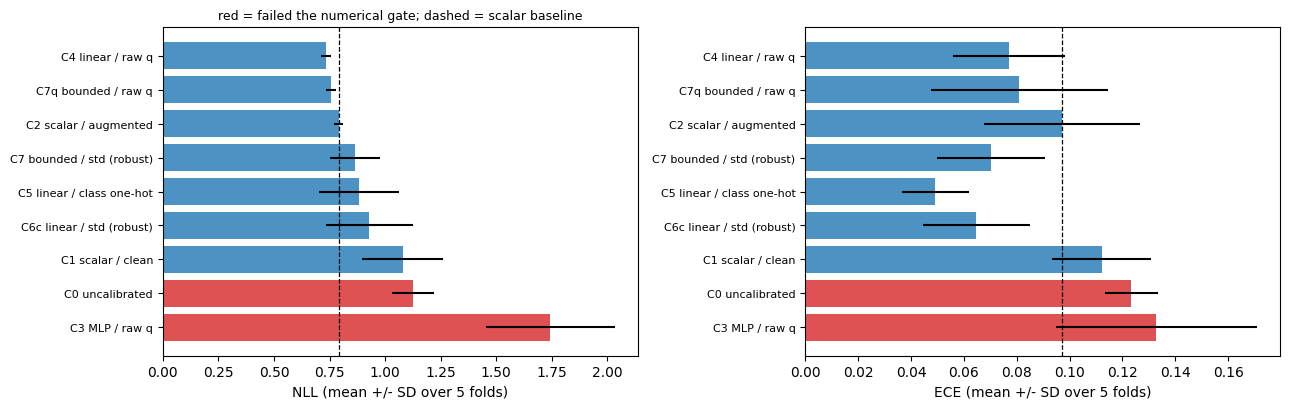

In [ ]:
#@title Trade-off view: likelihood versus calibration error
fig,ax=plt.subplots(1,2,figsize=(13,4.2))
srt=agg.sort_values("nll_mean")
for i,(m,sd,ttl) in enumerate([("nll_mean","nll_sd","NLL"),("ece_mean","ece_sd","ECE")]):
    col=["tab:red" if g!="sound" else "tab:blue" for g in srt.gate]
    ax[i].barh(range(len(srt)),srt[m],xerr=srt[sd].fillna(0),color=col,alpha=.8)
    ax[i].set_yticks(range(len(srt))); ax[i].set_yticklabels(srt.index,fontsize=8)
    ax[i].invert_yaxis(); ax[i].set_xlabel(f"{ttl} (mean +/- SD over 5 folds)")
    ax[i].axvline(agg.loc["C2 scalar / augmented",m],ls="--",c="k",lw=.9)
ax[0].set_title("red = failed the numerical gate; dashed = scalar baseline",fontsize=9)
plt.tight_layout(); plt.savefig(OUT/"phase0_8_tradeoff.png",dpi=200,bbox_inches="tight"); plt.show()

---

## What to carry into the paper

Whatever the verdict, four results are now established on five folds with image-level intervals
and no test-set peeking, and all four belong in the manuscript.

**Clean-fit calibration is worse than no calibration.** Fitted on clean validation data, scalar
temperature scaling drives *T* below 1 and *sharpens* an already-overconfident model. Report the
number; it motivates the entire paper in one line.

**The MLP temperature head fails.** 833 parameters, temperature pinned to the floor, likelihood
worse than uncalibrated. It is ablation evidence against capacity, not a component.

**C5 is the load-bearing control.** Any claim that a temperature tracks image quality rather than
class identity has to survive a calibrator that is handed the predicted class and nothing else.

**The leakage-corrected arm trades likelihood for calibration error.** Report both metrics for
every arm rather than the one that flatters the method.

## Still blocked, and not affected by any of this

KSDD2 from the official ViCoS release. Magnetic Tile folds rebuilt without the discarded pHash
grouping. The F1–F6 fixes applied to the main notebook. And this remains one backbone on one
dataset — the full experiment must show the result replicates across backbones and datasets
before any of it is a paper claim.